In [1]:
import anndata
from anndata import AnnData
import pandas as pd

#read in the gtf file to get the gene names and their corresponding chromosome locations & TSS
gtf_file = "/home/fgsasse_lrs_1/Downloads/BA/BA_data/Rmd_n_notebook/genomic.gtf"
gtf_df = pd.read_csv(gtf_file, sep="\t", header=None, comment="#")
gtf_df.columns = ["chr", "source", "feature", "start", "end", "score", "strand", "frame", "attribute"]
gtf_df["gene_name"] = gtf_df["attribute"].str.extract('gene_name "([^"]+)"')
gtf_df["gene_id"] = gtf_df["attribute"].str.extract('gene_id "([^"]+)"')
gtf_df = gtf_df[gtf_df["feature"] == "gene"]
gtf_df.tail()  

#load the pb_atac_ct peak names without headers and index column
pb_atac_ct_peaks = pd.read_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Pseudobulks/ATAC/celltypes/filtered_peaks_ct.csv", header= None,index_col=None)

In [ ]:
#remove the first row of the pb_atac_ct_peaks (and pb_atac_ct_time_peaks)
pb_atac_ct_peaks = pb_atac_ct_peaks.iloc[1:]

#give the column a name "chr_coord"
pb_atac_ct_peaks = pb_atac_ct_peaks.rename(columns={0: "peaks"})

#check the number of peak names in each file
print("Number of peaks in pb_atac_ct:", len(pb_atac_ct_peaks))

#show the first few rows of each file
print("First few rows of pb_atac_ct_peaks:")
print(pb_atac_ct_peaks.head())

#create a chromosome number column by splitting the peaks column at the underscore and taking the first part
pb_atac_ct_peaks["chr"] = pb_atac_ct_peaks["peaks"].str.split("-").str[0]       
print(pb_atac_ct_peaks.head())

#create peak coordinates (expected format: "chr_number-start-end")
peak_parts = pb_atac_ct_peaks["peaks"].astype(str).str.split("-", expand=True)
pb_atac_ct_peaks["chr_number"] = pd.to_numeric(peak_parts[0], errors="coerce")
pb_atac_ct_peaks["peak_start"] = pd.to_numeric(peak_parts[1], errors="coerce")
pb_atac_ct_peaks["peak_end"] = pd.to_numeric(peak_parts[2], errors="coerce")

# Keep only peaks with valid numeric chromosome/start/end
pb_atac_ct_peaks = pb_atac_ct_peaks.dropna(subset=["chr_number", "peak_start", "peak_end"]).copy()
pb_atac_ct_peaks[["chr_number", "peak_start", "peak_end"]] = (
    pb_atac_ct_peaks[["chr_number", "peak_start", "peak_end"]].astype(int)
)


Number of peaks in pb_atac_ct: 640832
First few rows of pb_atac_ct_peaks:
         peaks
1     1-32-526
2  1-2372-3057
3  1-3427-4032
4  1-4469-7268
5  1-9541-9969
         peaks chr
1     1-32-526   1
2  1-2372-3057   1
3  1-3427-4032   1
4  1-4469-7268   1
5  1-9541-9969   1


In [3]:
#Subset the columns to only include gene_id, chr, start, end, strand, then keep only chr starting with "NC"
TSS_subset = gtf_df[["gene_id", "chr", "start", "end", "strand"]]
TSS_subset = TSS_subset[TSS_subset["chr"].str.startswith("NC")]    
#remove mitochondrial chromosome
TSS_subset = TSS_subset[~TSS_subset["chr"].str.endswith(".2")]
unique_chromosomes = TSS_subset["chr"].unique()
print(unique_chromosomes)

['NC_007112.7' 'NC_007113.7' 'NC_007114.7' 'NC_007115.7' 'NC_007116.7'
 'NC_007117.7' 'NC_007118.7' 'NC_007119.7' 'NC_007120.7' 'NC_007121.7'
 'NC_007122.7' 'NC_007123.7' 'NC_007124.7' 'NC_007125.7' 'NC_007126.7'
 'NC_007127.7' 'NC_007128.7' 'NC_007129.7' 'NC_007130.7' 'NC_007131.7'
 'NC_007132.7' 'NC_007133.7' 'NC_007134.7' 'NC_007135.7' 'NC_007136.7']


In [4]:
#Filtering the gene_id column by the gene names in csv file
gene_names = pd.read_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Pseudobulks/RNA/celltypes/filtered_genes_ct.csv", header=None, index_col=None)
gene_names = gene_names.iloc[:, 0].tolist()  # Convert the single column to a list
TSS_filtered = TSS_subset[TSS_subset["gene_id"].isin(gene_names)]
print("Number of genes in TSS_filtered:", len(TSS_filtered))
print("First few rows of TSS_filtered:")

#show some gene names in the list, which were not filtered by the gene names in the csv file
unfiltered_genes = [gene for gene in dict.fromkeys(gene_names) if gene not in TSS_filtered["gene_id"].unique()]  
print("Some gene names that were not in the TSS_subset:")
print(unfiltered_genes[:10])  # Print the first 10 unfiltered gene names

#Show if phtf2 is in the TSS_filtered gene_id column
if "phtf2" in TSS_filtered["gene_id"].values:
    print("phtf2 is in the TSS_filtered gene_id column")
else:
    print("phtf2 is not in the TSS_filtered gene_id column")    

Number of genes in TSS_filtered: 19380
First few rows of TSS_filtered:
Some gene names that were not in the TSS_subset:
['0', 'phtf2.1', 'CU856344.1', 'ptpro.1', 'RERG', 'CABZ01085275.1', 'FO834823.1', 'dynlt1', 'BX890562.1', 'BX890562.3']
phtf2 is in the TSS_filtered gene_id column


In [5]:
#Saving the unfiltered gene names to a csv file
unfiltered_genes_df = pd.DataFrame(unfiltered_genes, columns=["unfiltered_gene_names"])
unfiltered_genes_df.to_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Rmd_n_notebook/unfiltered_genes_windows.csv", index=False)

#Saving the filtered gene names to a csv file
filtered_genes_df = pd.DataFrame(TSS_filtered["gene_id"].unique(), columns=["filtered_gene_names"])
filtered_genes_df.to_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Rmd_n_notebook/filtered_genes_windows.csv", index=False)

In [6]:
#find gene names in gene_name list that start with "NC" and count how many there are
nuclear_genes = [gene for gene in gene_names if gene.startswith("NC")]
print(f"Number of genes with 'NC' in their name: {len(nuclear_genes)}")

mt_genes = [gene for gene in gene_names if gene.startswith("MT")]
print(f"Number of genes with 'MT' in their name: {len(mt_genes)}")  

Number of genes with 'NC' in their name: 26
Number of genes with 'MT' in their name: 2


In [7]:
#Creating a window of 10kb, 20kb, 50kb, and 100kb around the TSS of each gene
TSS_filtered["TSS"] = TSS_filtered.apply(lambda row: row["start"] if row["strand"] == "+" else row["end"], axis=1)
TSS_filtered["TSS_10kb_start"] = TSS_filtered["TSS"] - 10000
TSS_filtered["TSS_10kb_end"] = TSS_filtered["TSS"] + 10000
TSS_filtered["TSS_20kb_start"] = TSS_filtered["TSS"] - 20000
TSS_filtered["TSS_20kb_end"] = TSS_filtered["TSS"] + 20000
TSS_filtered["TSS_50kb_start"] = TSS_filtered["TSS"] - 50000
TSS_filtered["TSS_50kb_end"] = TSS_filtered["TSS"] + 50000
TSS_filtered["TSS_100kb_start"] = TSS_filtered["TSS"] - 100000
TSS_filtered["TSS_100kb_end"] = TSS_filtered["TSS"] + 100000  

TSS_filtered.head()


/tmp/ipykernel_3993549/1670774818.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  TSS_filtered["TSS"] = TSS_filtered.apply(lambda row: row["start"] if row["strand"] == "+" else row["end"], axis=1)
/tmp/ipykernel_3993549/1670774818.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  TSS_filtered["TSS_10kb_start"] = TSS_filtered["TSS"] - 10000
/tmp/ipykernel_3993549/1670774818.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_i

,gene_id,chr,start,end,strand,TSS,TSS_10kb_start,TSS_10kb_end,TSS_20kb_start,TSS_20kb_end,TSS_50kb_start,TSS_50kb_end,TSS_100kb_start,TSS_100kb_end
0,rpl24,NC_007112.7,6642,11878,-,11878,1878,21878,-8122,31878,-38122,61878,-88122,111878
16,cep97,NC_007112.7,11961,16373,+,11961,1961,21961,-8039,31961,-38039,61961,-88039,111961
67,nfkbiz,NC_007112.7,18631,23837,+,18631,8631,28631,-1369,38631,-31369,68631,-81369,118631
95,eed,NC_007112.7,27688,34330,+,27688,17688,37688,7688,47688,-22312,77688,-72312,127688
123,hikeshi,NC_007112.7,36734,39191,+,36734,26734,46734,16734,56734,-13266,86734,-63266,136734


In [8]:
#counting the number of genes on each chromosome that have a negative start position for each window size, and the number of genes on each window size 
for window in ["10kb", "20kb", "50kb", "100kb"]:
    count = len(TSS_filtered[TSS_filtered[f"TSS_{window}_start"] < 0])
    print(f"Number of genes with negative start position for {window} window: {count}")

for window in ["10kb", "20kb", "50kb", "100kb"]:
    count = TSS_filtered[f"TSS_{window}_end"].notna().sum()
    print(f"Number of genes for {window} window: {count}") 

for window in ["10kb", "20kb", "50kb", "100kb"]:
    count = len(TSS_filtered[TSS_filtered[f"TSS_{window}_end"] < 0])
    print(f"Number of genes with negative end position for {window} window: {count}")

Number of genes with negative start position for 10kb window: 7
Number of genes with negative start position for 20kb window: 17
Number of genes with negative start position for 50kb window: 42
Number of genes with negative start position for 100kb window: 82
Number of genes for 10kb window: 19380
Number of genes for 20kb window: 19380
Number of genes for 50kb window: 19380
Number of genes for 100kb window: 19380
Number of genes with negative end position for 10kb window: 0
Number of genes with negative end position for 20kb window: 0
Number of genes with negative end position for 50kb window: 0
Number of genes with negative end position for 100kb window: 0


In [9]:
#Replacing negative start positions with 0
for window in ["10kb", "20kb", "50kb", "100kb"]:
    TSS_filtered[f"TSS_{window}_start"] = TSS_filtered[f"TSS_{window}_start"].apply(lambda x: max(x, 0))    

for window in ["10kb", "20kb", "50kb", "100kb"]:
    count = len(TSS_filtered[TSS_filtered[f"TSS_{window}_start"] < 0])
    print(f"Number of genes with negative start position for {window} window: {count}")

Number of genes with negative start position for 10kb window: 0
Number of genes with negative start position for 20kb window: 0
Number of genes with negative start position for 50kb window: 0
Number of genes with negative start position for 100kb window: 0


/tmp/ipykernel_3993549/3964378443.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  TSS_filtered[f"TSS_{window}_start"] = TSS_filtered[f"TSS_{window}_start"].apply(lambda x: max(x, 0))


In [11]:
#Creat a chromosome number column by first sorting the chr column and then adding a number starting from 1 for the first unique chromosome and incrementing by 1 for each subsequent unique chromosome
TSS_filtered["chr_number"] = TSS_filtered["chr"].astype("category").cat.codes + 1

#Show the chr and chr_number columns to check that the chromosome numbers are correct
print(TSS_filtered[["chr", "chr_number"]].drop_duplicates().sort_values("chr_number"))

#Create for each window a dataframe with a chromosome coordinate column by concatenating the chr_number, start, and end columns with a "-" in between
TSS_filtered["chr_coord_10kb"] = TSS_filtered["chr_number"].astype(str) + "-" + TSS_filtered["TSS_10kb_start"].astype(str) + "-" + TSS_filtered["TSS_10kb_end"].astype(str)     
TSS_filtered["chr_coord_20kb"] = TSS_filtered["chr_number"].astype(str) + "-" + TSS_filtered["TSS_20kb_start"].astype(str) + "-" + TSS_filtered["TSS_20kb_end"].astype(str)
TSS_filtered["chr_coord_50kb"] = TSS_filtered["chr_number"].astype(str) + "-" + TSS_filtered["TSS_50kb_start"].astype(str) + "-" + TSS_filtered["TSS_50kb_end"].astype(str)             
TSS_filtered["chr_coord_100kb"] = TSS_filtered["chr_number"].astype(str) + "-" + TSS_filtered["TSS_100kb_start"].astype(str) + "-" + TSS_filtered["TSS_100kb_end"].astype(str)
TSS_filtered.head()

#save the TSS_filtered dataframe to a csv file
TSS_filtered.to_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Rmd_n_notebook/TSS_filtered_windows.csv", index=False)

                 chr  chr_number
0        NC_007112.7           1
66938    NC_007113.7           2
130912   NC_007114.7           3
194840   NC_007115.7           4
297449   NC_007116.7           5
384090   NC_007117.7           6
455914   NC_007118.7           7
545366   NC_007119.7           8
604812   NC_007120.7           9
678934   NC_007121.7          10
734651   NC_007122.7          11
786719   NC_007123.7          12
842547   NC_007124.7          13
902567   NC_007125.7          14
941208   NC_007126.7          15
995541   NC_007127.7          16
1055235  NC_007128.7          17
1118397  NC_007129.7          18
1161820  NC_007130.7          19
1217004  NC_007131.7          20
1281034  NC_007132.7          21
1337731  NC_007133.7          22
1384050  NC_007134.7          23
1444602  NC_007135.7          24
1487927  NC_007136.7          25


/tmp/ipykernel_3993549/344241673.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  TSS_filtered["chr_number"] = TSS_filtered["chr"].astype("category").cat.codes + 1
/tmp/ipykernel_3993549/344241673.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  TSS_filtered["chr_coord_10kb"] = TSS_filtered["chr_number"].astype(str) + "-" + TSS_filtered["TSS_10kb_start"].astype(str) + "-" + TSS_filtered["TSS_10kb_end"].astype(str)
/tmp/ipykernel_3993549/344241673.py:9: SettingWithCopyWarning: 
A value is trying to be 

In [13]:
# Change chr to integer
pb_atac_ct_peaks["chr"] = pb_atac_ct_peaks["chr"].astype(int)
TSS_filtered["chr_number"] = TSS_filtered["chr_number"].astype(int)

/tmp/ipykernel_441678/3742898791.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  TSS_filtered["chr_number"] = TSS_filtered["chr_number"].astype(int)


In [59]:
# dictionary to save per gene assignments for window size 10kb
gene_peak_assignments_10kb = {}
# loop over genes
for row in TSS_filtered.itertuples():
    window_chr = row.chr_number
    window_start = row.TSS_10kb_start
    window_end = row.TSS_10kb_end
    window_peaks = pb_atac_ct_peaks[(pb_atac_ct_peaks['chr'] == window_chr) & (pb_atac_ct_peaks['peak_start'] >= window_start) & (pb_atac_ct_peaks['peak_end'] <= window_end)]
    gene_peak_assignments_10kb[row.gene_id] = window_peaks['peaks'].tolist()

In [60]:
# dictionary to save per gene assignments for window size 20kb
gene_peak_assignments_20kb = {}
# loop over genes
for row in TSS_filtered.itertuples():
    window_chr = row.chr_number
    window_start = row.TSS_20kb_start
    window_end = row.TSS_20kb_end
    window_peaks = pb_atac_ct_peaks[(pb_atac_ct_peaks['chr']==window_chr) & (pb_atac_ct_peaks['peak_start'] >= window_start) & (pb_atac_ct_peaks['peak_end'] <= window_end)]
    gene_peak_assignments_20kb[row.gene_id] = window_peaks['peaks'].tolist()

In [61]:
# dictionary to save per gene assignments for window size 50kb

gene_peak_assignments_50kb = {}
# loop over genes
for row in TSS_filtered.itertuples():
    window_chr = row.chr_number
    window_start = row.TSS_50kb_start
    window_end = row.TSS_50kb_end
    window_peaks = pb_atac_ct_peaks[(pb_atac_ct_peaks['chr'] == window_chr) & (pb_atac_ct_peaks['peak_start'] >= window_start) & (pb_atac_ct_peaks['peak_end'] <= window_end)]
    gene_peak_assignments_50kb[row.gene_id] = window_peaks['peaks'].tolist()

In [62]:
# dictionary to save per gene assignments for window size 100kb
gene_peak_assignments_100kb = {}
# loop over genes
for row in TSS_filtered.itertuples():
    window_chr = row.chr_number
    window_start = row.TSS_100kb_start
    window_end = row.TSS_100kb_end
    window_peaks = pb_atac_ct_peaks[(pb_atac_ct_peaks['chr']==window_chr) & (pb_atac_ct_peaks['peak_start'] >= window_start) & (pb_atac_ct_peaks['peak_end'] <= window_end)]
    gene_peak_assignments_100kb[row.gene_id] = window_peaks['peaks'].tolist()

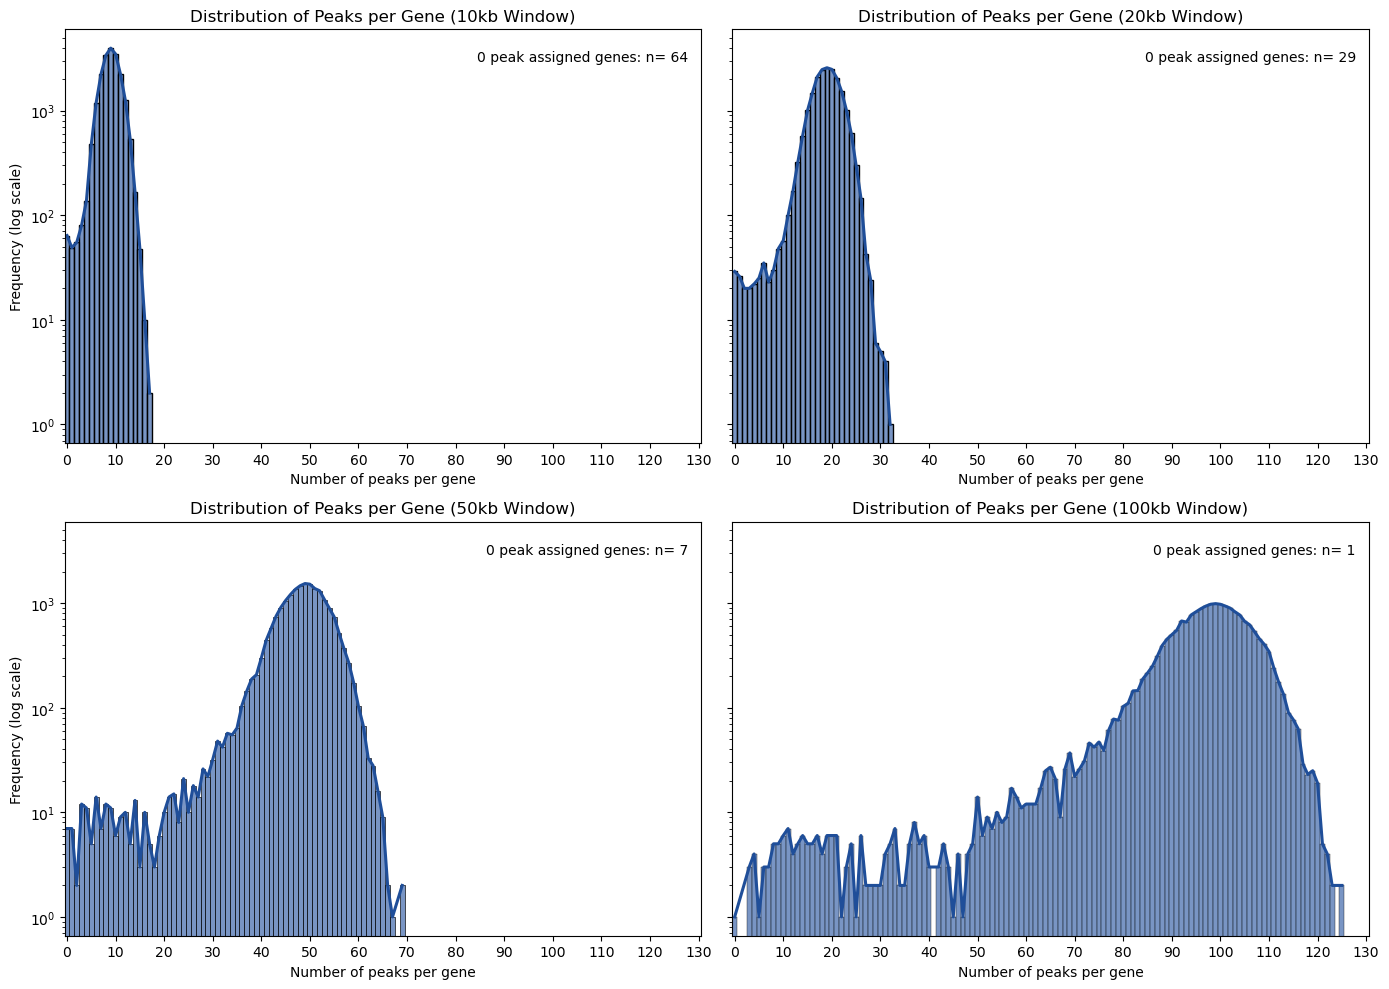

In [ ]:
# Plot distribution of peaks per gene for all window sizes with seaborn
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

window_assignments = {
    "10kb": gene_peak_assignments_10kb,
    "20kb": gene_peak_assignments_20kb,
    "50kb": gene_peak_assignments_50kb,
    "100kb": gene_peak_assignments_100kb,
}


def choose_tick_step(max_count: int) -> int:
    if max_count <= 20:
        return 1
    if max_count <= 50:
        return 2
    if max_count <= 100:
        return 5
    if max_count <= 200:
        return 10
    if max_count <= 500:
        return 20
    return 50


# Build counts once so all plots can share the same x-axis scale
window_counts = {
    label: np.asarray([len(peaks) for peaks in assignments.values()], dtype=int)
    for label, assignments in window_assignments.items()
}

non_empty_maxima = [int(counts.max()) for counts in window_counts.values() if counts.size > 0]
global_max_count = max(non_empty_maxima) if non_empty_maxima else 0
global_tick_step = choose_tick_step(global_max_count)
global_tick_max = int(np.ceil(global_max_count / global_tick_step) * global_tick_step) if global_max_count > 0 else global_tick_step
global_xticks = np.arange(0, global_tick_max + global_tick_step, global_tick_step)

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharey=True)
axes = axes.flatten()

for ax, (window_label, assignments) in zip(axes, window_assignments.items()):
    counts = window_counts[window_label]
    zero_peak_genes = int(np.sum(counts == 0)) if counts.size > 0 else 0

    if counts.size == 0:
        ax.set_title(f"Distribution of Peaks per Gene ({window_label} Window)")
        ax.set_xlabel("Number of peaks per gene")
        ax.set_ylabel("Frequency (log scale)")
        ax.set_xlim(-0.5, global_tick_max + 0.5)
        ax.set_xticks(global_xticks)
        ax.text(0.5, 0.5, "No data", transform=ax.transAxes, ha="center", va="center")
        ax.text(
            0.98,
            0.95,
            f"0 peak assigned genes: n= {zero_peak_genes}",
            transform=ax.transAxes,
            ha="right",
            va="top",
            fontsize=10,
            bbox={"boxstyle": "round,pad=0.25", "facecolor": "white", "alpha": 0.75, "edgecolor": "none"},
        )
        continue

    bins = np.arange(-0.5, int(counts.max()) + 1.5, 1)
    sns.histplot(counts, bins=bins, color="#4C72B0", ax=ax)

    # Raw frequency line (no smoothing); hide zero-frequency points for log scale
    hist_counts, edges = np.histogram(counts, bins=bins)
    centers = (edges[:-1] + edges[1:]) / 2
    line_y = np.where(hist_counts > 0, hist_counts, np.nan)
    sns.lineplot(x=centers, y=line_y, ax=ax, color="#1F4E99", linewidth=2.2)

    ax.set_yscale("log")
    ax.set_xlabel("Number of peaks per gene")
    ax.set_ylabel("Frequency (log scale)")
    ax.set_title(f"Distribution of Peaks per Gene ({window_label} Window)")
    ax.set_xlim(-0.5, global_tick_max + 0.5)
    ax.set_xticks(global_xticks)
    ax.text(
        0.98,
        0.95,
        f"0 peak assigned genes: n= {zero_peak_genes}",
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=10,
        bbox={"boxstyle": "round,pad=0.25", "facecolor": "white", "alpha": 0.75, "edgecolor": "none"},
    )

plt.tight_layout()
plt.show()

# Save each subplot separately with the window size in the file name
for window_label, assignments in window_assignments.items():
    fig_single, ax_single = plt.subplots(figsize=(7, 5))
    counts = window_counts[window_label]
    zero_peak_genes = int(np.sum(counts == 0)) if counts.size > 0 else 0

    if counts.size > 0:
        bins = np.arange(-0.5, int(counts.max()) + 1.5, 1)
        sns.histplot(counts, bins=bins, color="#4C72B0", ax=ax_single)

        # Raw frequency line (no smoothing); hide zero-frequency points for log scale
        hist_counts, edges = np.histogram(counts, bins=bins)
        centers = (edges[:-1] + edges[1:]) / 2
        line_y = np.where(hist_counts > 0, hist_counts, np.nan)
        sns.lineplot(x=centers, y=line_y, ax=ax_single, color="#1F4E99", linewidth=2.2)
    else:
        ax_single.text(0.5, 0.5, "No data", transform=ax_single.transAxes, ha="center", va="center")

    ax_single.set_yscale("log")
    ax_single.set_xlabel("Number of peaks per gene")
    ax_single.set_ylabel("Frequency (log scale)")
    ax_single.set_title(f"Distribution of Peaks per Gene ({window_label} Window)")
    ax_single.set_xlim(-0.5, global_tick_max + 0.5)
    ax_single.set_xticks(global_xticks)
    ax_single.text(
        0.98,
        0.95,
        f"0 peak assigned genes: n= {zero_peak_genes}",
        transform=ax_single.transAxes,
        ha="right",
        va="top",
        fontsize=10,
        bbox={"boxstyle": "round,pad=0.25", "facecolor": "white", "alpha": 0.75, "edgecolor": "none"},
    )

    plt.tight_layout()
    fig_single.savefig(f"peak_distribution_{window_label}_window.png", dpi=300)
    plt.close(fig_single)



In [67]:
#check if there are any genes with 0 peaks assigned to them for the 10kb window
genes_with_zero_peaks_10kb = [gene for gene, peaks in gene_peak_assignments_10kb.items() if len(peaks) == 0]
print(f"Number of genes with 0 peaks assigned (10kb window): {len(genes_with_zero_peaks_10kb)}")    

genes_with_zero_peaks_20kb = [gene for gene, peaks in gene_peak_assignments_20kb.items() if len(peaks) == 0]
print(f"Number of genes with 0 peaks assigned (20kb window): {len(genes_with_zero_peaks_20kb)}")    

genes_with_zero_peaks_50kb = [gene for gene, peaks in gene_peak_assignments_50kb.items() if len(peaks) == 0]
print(f"Number of genes with 0 peaks assigned (50kb window): {len(genes_with_zero_peaks_50kb)}")

genes_with_zero_peaks_100kb = [gene for gene, peaks in gene_peak_assignments_100kb.items() if len(peaks) == 0]
print(f"Number of genes with 0 peaks assigned (100kb window): {len(genes_with_zero_peaks_100kb)}")
    

Number of genes with 0 peaks assigned (10kb window): 64
Number of genes with 0 peaks assigned (20kb window): 29
Number of genes with 0 peaks assigned (50kb window): 7
Number of genes with 0 peaks assigned (100kb window): 1


In [ ]:
#Genes with 0 peaks assigned in the 20kb window
TSS_filtered[TSS_filtered["gene_id"].isin(genes_with_zero_peaks_20kb)]

,gene_id,chr,start,end,strand,TSS,TSS_10kb_start,TSS_10kb_end,TSS_20kb_start,TSS_20kb_end,TSS_50kb_start,TSS_50kb_end,TSS_100kb_start,TSS_100kb_end,chr_number,chr_coord_10kb,chr_coord_20kb,chr_coord_50kb,chr_coord_100kb
138077,rnps1,NC_007114.7,9432442,9444242,-,9444242,9434242,9454242,9424242,9464242,9394242,9494242,9344242,9544242,3,3-9434242-9454242,3-9424242-9464242,3-9394242-9494242,3-9344242-9544242
138142,zmp:0000000997,NC_007114.7,9496077,9496959,-,9496959,9486959,9506959,9476959,9516959,9446959,9546959,9396959,9596959,3,3-9486959-9506959,3-9476959-9516959,3-9446959-9546959,3-9396959-9596959
251236,zgc:174698,NC_007115.7,35412545,35444692,+,35412545,35402545,35422545,35392545,35432545,35362545,35462545,35312545,35512545,4,4-35402545-35422545,4-35392545-35432545,4-35362545-35462545,4-35312545-35512545
254440,si:dkey-59l11.10,NC_007115.7,38815364,38829118,-,38829118,38819118,38839118,38809118,38849118,38779118,38879118,38729118,38929118,4,4-38819118-38839118,4-38809118-38849118,4-38779118-38879118,4-38729118-38929118
254749,si:dkey-122c11.8,NC_007115.7,39105129,39110996,-,39110996,39100996,39120996,39090996,39130996,39060996,39160996,39010996,39210996,4,4-39100996-39120996,4-39090996-39130996,4-39060996-39160996,4-39010996-39210996
256486,zgc:174650,NC_007115.7,40878969,40883162,-,40883162,40873162,40893162,40863162,40903162,40833162,40933162,40783162,40983162,4,4-40873162-40893162,4-40863162-40903162,4-40833162-40933162,4-40783162-40983162
257207,si:dkey-237m9.1,NC_007115.7,41816783,41825146,-,41825146,41815146,41835146,41805146,41845146,41775146,41875146,41725146,41925146,4,4-41815146-41835146,4-41805146-41845146,4-41775146-41875146,4-41725146-41925146
261010,si:dkey-51d8.1,NC_007115.7,44997263,45028479,-,45028479,45018479,45038479,45008479,45048479,44978479,45078479,44928479,45128479,4,4-45018479-45038479,4-45008479-45048479,4-44978479-45078479,4-44928479-45128479
262915,si:dkey-124l13.1,NC_007115.7,47437224,47454779,+,47437224,47427224,47447224,47417224,47457224,47387224,47487224,47337224,47537224,4,4-47427224-47447224,4-47417224-47457224,4-47387224-47487224,4-47337224-47537224
268296,si:dkey-201g16.1,NC_007115.7,52960429,52968143,+,52960429,52950429,52970429,52940429,52980429,52910429,53010429,52860429,53060429,4,4-52950429-52970429,4-52940429-52980429,4-52910429-53010429,4-52860429-53060429


In [68]:
#Create a dataframe with the gene_id and the peaks assigned to each gene for all window sizes, and save it as a csv file
gene_peak_assignments_10kb_df = pd.DataFrame({
    "gene_id": list(gene_peak_assignments_10kb.keys()),
    "assigned_peaks": list(gene_peak_assignments_10kb.values())
})
gene_peak_assignments_10kb_df.to_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Rmd_n_notebook/gene_peak_assignments_10kb.csv", index=False) 

gene_peak_assignments_20kb_df = pd.DataFrame({
    "gene_id": list(gene_peak_assignments_20kb.keys()),
    "assigned_peaks": list(gene_peak_assignments_20kb.values())
})
gene_peak_assignments_20kb_df.to_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Rmd_n_notebook/gene_peak_assignments_20kb.csv", index=False) 

gene_peak_assignments_50kb_df = pd.DataFrame({
    "gene_id": list(gene_peak_assignments_50kb.keys()),
    "assigned_peaks": list(gene_peak_assignments_50kb.values())
})
gene_peak_assignments_50kb_df.to_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Rmd_n_notebook/gene_peak_assignments_50kb.csv", index=False) 

gene_peak_assignments_100kb_df = pd.DataFrame({
    "gene_id": list(gene_peak_assignments_100kb.keys()),
    "assigned_peaks": list(gene_peak_assignments_100kb.values())
})
gene_peak_assignments_100kb_df.to_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Rmd_n_notebook/gene_peak_assignments_100kb.csv", index=False)               

In [202]:
gene_peak_assignments_10kb["rpl24"]

['1-2372-3057',
 '1-3427-4032',
 '1-4469-7268',
 '1-9541-9969',
 '1-11007-12962',
 '1-13276-13705',
 '1-14059-14260',
 '1-14625-15105',
 '1-15724-15934',
 '1-16762-17233',
 '1-17587-18215',
 '1-18372-20466',
 '1-21199-21555']

In [204]:
# Compare assigned peaks for gene "rpl24" between dataframe and dictionary
peaks_from_df = gene_peak_assignments_10kb_df.loc[
    gene_peak_assignments_10kb_df["gene_id"] == "rpl24", "assigned_peaks"
].iloc[0]
peaks_from_dict = gene_peak_assignments_10kb["rpl24"]

# True means both sources contain the same peak list
peaks_from_df == peaks_from_dict

True